<a href="https://colab.research.google.com/github/jahnavimala/Customer-Segmentation-Analysis/blob/main/week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shwetabh123/mall-customers")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mall-customers' dataset.
Path to dataset files: /kaggle/input/mall-customers


In [ ]:
data = pd.read_csv(f"{path}/Mall_Customers.csv")

In [ ]:
data['Genre'] = data['Genre'].map({'Male':0, 'Female':1})

In [ ]:
X=data[['Age', 'Genre', 'Spending Score (1-100)']]

In [ ]:
Scaler=StandardScaler()
X_scaled=Scaler.fit_transform(X)
wcss=[]

In [ ]:
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

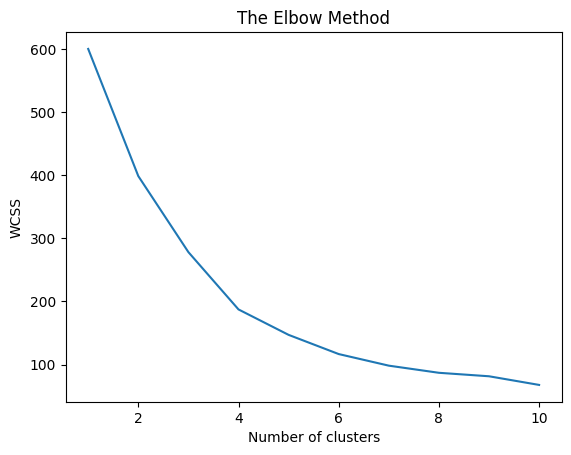

In [ ]:
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42)
data['Cluster']=kmeans.fit_predict(X_scaled)


In [ ]:
print(data.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1      0   19                  15                      39        2
1           2      0   21                  15                      81        2
2           3      1   20                  16                       6        1
3           4      1   23                  16                      77        3
4           5      1   31                  17                      40        3
